In [1]:
from astropy.table import Table
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import pandas as pd

#### Problem 1

In [2]:
p1 = pd.read_csv('SSDS_HW2.csv')

(array([ 6118., 15674., 25919., 20548., 15987.,  8940.,  4275.,  1735.,
          625.,   179.]),
 array([4.20712083e+04, 1.25032156e+08, 2.50022240e+08, 3.75012325e+08,
        5.00002409e+08, 6.24992494e+08, 7.49982578e+08, 8.74972663e+08,
        9.99962748e+08, 1.12495283e+09, 1.24994292e+09]),
 <BarContainer object of 10 artists>)

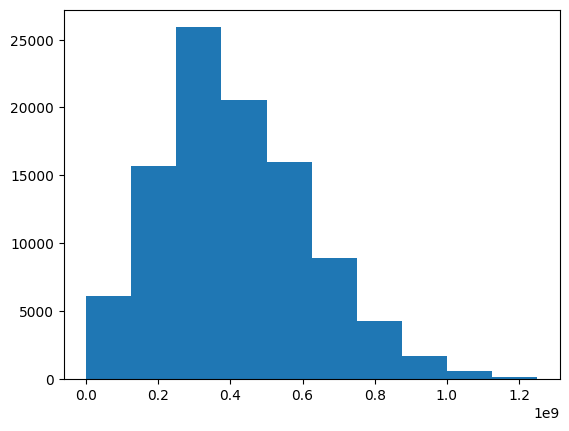

In [3]:
#Finding distance to the objects
z = p1['z']
v = z * 3e5
d = v / 72 * 1e6
plt.hist(d)

In [4]:
Abs_R = 5 + p1['dered_r'] - (5 * np.log10(d))

In [5]:
p1['distance'] = (10**((22.5 - Abs_R)/5))/10**6

In [6]:
Vmax = (4/3) * np.pi * p1['distance']**3

Text(0.5, 0, 'Absolute Magnitude')

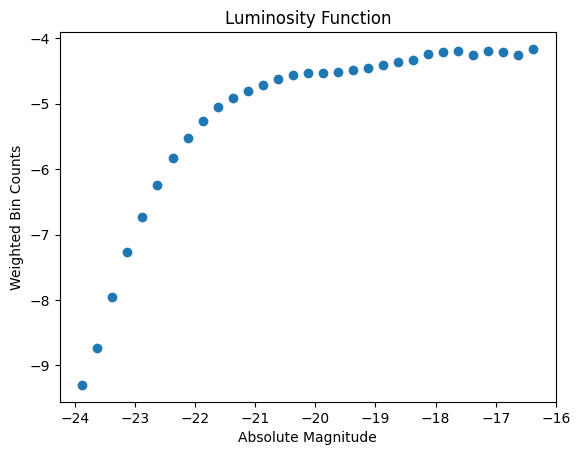

In [7]:
mbins=np.arange(-24,-16,0.25)
hist,edges=np.histogram(Abs_R,bins=mbins,weights=1/Vmax)
bincenters=0.5*(mbins[1:]+mbins[:-1])
logN=np.log10(hist)
plt.scatter(bincenters,logN)
plt.title("Luminosity Function")
plt.ylabel("Weighted Bin Counts")
plt.xlabel("Absolute Magnitude")

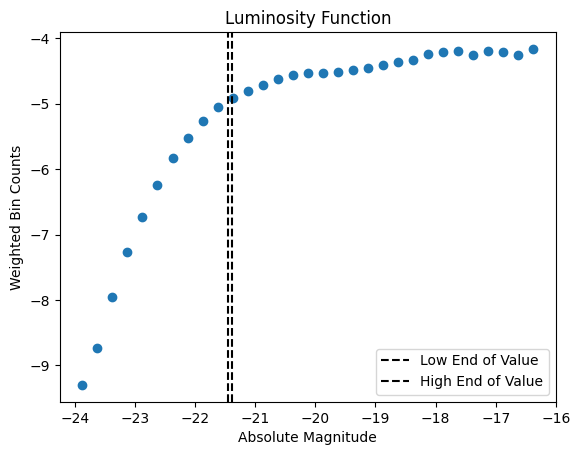

In [8]:
mbins=np.arange(-24,-16,0.25)
hist,edges=np.histogram(Abs_R,bins=mbins,weights=1/Vmax)
bincenters=0.5*(mbins[1:]+mbins[:-1])
logN=np.log10(hist)
plt.axvline(-21.42+0.04, color = "black", linestyle='--', label = "Low End of Value")
plt.axvline(-21.42-0.04, color = "black", linestyle='--', label = "High End of Value")

plt.scatter(bincenters,logN)
plt.title("Luminosity Function")
plt.ylabel("Weighted Bin Counts")
plt.xlabel("Absolute Magnitude")
plt.legend()

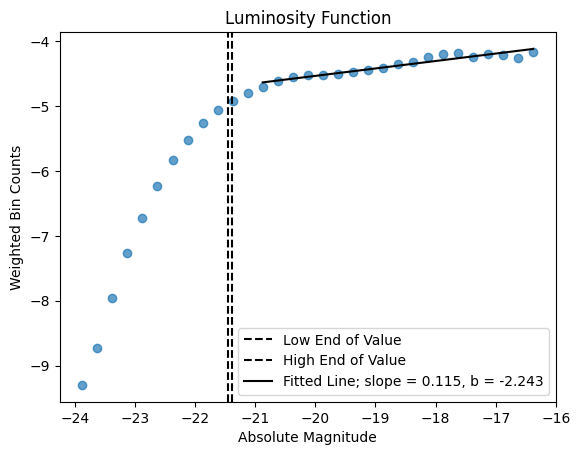

In [9]:
mbins=np.arange(-24,-16,0.25)
hist,edges=np.histogram(Abs_R,bins=mbins,weights=1/Vmax)
bincenters=0.5*(mbins[1:]+mbins[:-1])
logN=np.log10(hist)
plt.axvline(-21.42+0.04, color = "black", linestyle='--', label = "Low End of Value")
plt.axvline(-21.42-0.04, color = "black", linestyle='--', label = "High End of Value")

x_fit_range = (-21, -16)
mask = (bincenters >= x_fit_range[0]) & (bincenters <= x_fit_range[1])
x_selected = bincenters[mask]
y_selected = logN[mask]

slope, intercept = np.polyfit(x_selected, y_selected, deg=1)
y_fit = slope * x_selected + intercept


plt.plot(x_selected, y_fit, color='black', label=f'Fitted Line; slope = {slope:.3f}, b = {intercept:.3f}')
plt.legend()
plt.title("MS Branch")


plt.scatter(bincenters,logN, alpha = 0.7)
plt.title("Luminosity Function")
plt.ylabel("Weighted Bin Counts")
plt.xlabel("Absolute Magnitude")
plt.legend()

#### Problem 4

In [10]:
filename='Gaia_bLT10_pGT5.fits'
if not os.path.isfile(filename):
 gaia_data=Table.read('https://burro.case.edu/Academics/Astr323/HW/HW2/'+filename)
 gaia_data.write(filename)
else:
 gaia_data=Table.read(filename)

#Changing the variables to the correct units
gaia_data['parallax'] = gaia_data['parallax']/1000
gaia_data['pmra'] = gaia_data['pmra']/1000
gaia_data['pmdec'] = gaia_data['pmdec']/1000
gaia_data['pml'] = gaia_data['pml']/1000
gaia_data['pmb'] = gaia_data['pmb']/1000

In [11]:
gaia_data['distance'] = 1/gaia_data['parallax']
gaia_data['absolute_mag'] = 5 + gaia_data['phot_g_mean_mag'] - 5*np.log10(gaia_data['distance'])

In [12]:
bp_rp=gaia_data['bp_rp']
MG= gaia_data['absolute_mag']

Text(0.5, 1.0, 'Full CMD of Gaia Data (4)')

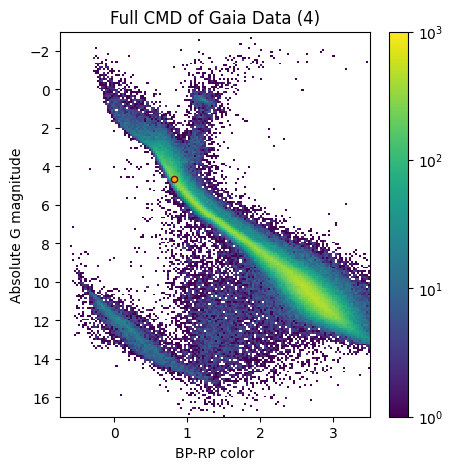

In [13]:
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(111)
h = ax.hist2d(bp_rp, MG, bins=(np.linspace(-0.75,3.5,151),np.linspace(-3,17,201)), norm=LogNorm(1.0,1e3))
cb = fig.colorbar(h[3])
cb.ax.minorticks_off()
ax.invert_yaxis()
ax.set_xlabel('BP-RP color')
ax.set_ylabel('Absolute G magnitude')
ax.set_yticks(np.arange(-2,18,2))
ax.scatter([0.82], [4.67], color='orange', edgecolor='#661100', s=20, lw=1)
ax.set_title("Full CMD of Gaia Data (4)")

In [14]:
gaia_data['w_vel'] = 4.74 * gaia_data['pmb']*gaia_data['distance']

In [15]:
rgb_stars = gaia_data['star_type']==2
main_seq = gaia_data['star_type']==1
blue = gaia_data['bp_rp'] < 0.5
blue_ms = gaia_data['star_type'][main_seq & blue]

In [16]:
w_velocities_greater = gaia_data['w_vel'] >= -75
w_velocities_less = gaia_data['w_vel'] <= 75
w_vel = gaia_data['w_vel'][w_velocities_greater & w_velocities_less]

w_vel_rgb = gaia_data['w_vel'][w_velocities_greater & w_velocities_less & rgb_stars]
w_vel_ms = gaia_data['w_vel'][w_velocities_greater & w_velocities_less & main_seq]
w_vel_blue = gaia_data['w_vel'][w_velocities_greater & w_velocities_less & blue & main_seq]

C:\Users\bhoom\AppData\Local\Temp\ipykernel_9988\818190329.py:8: RuntimeWarning: divide by zero encountered in log10
  logN = np.log10(N)



AVGERAGE: -7.475752272480465, DISPERSION: 19.073168229102016


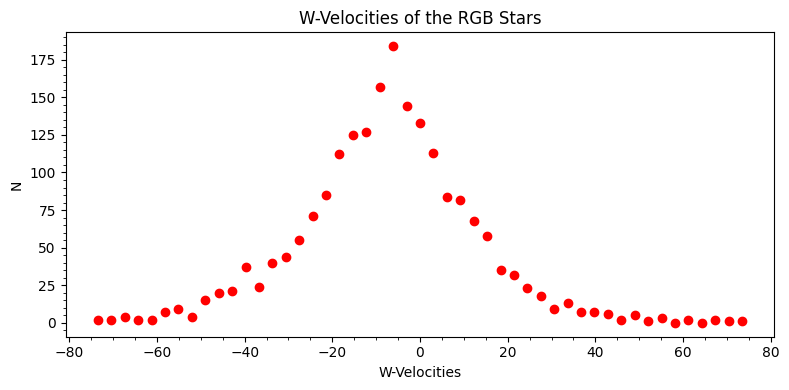

In [17]:
Fig,(linPlot) = plt.subplots(1,figsize=(8,4))
magbins=np.linspace(-75,75,50)
# use np.histogram to actually give us the counts and bins
# in variables that we can work with
N,bin_edges = np.histogram(w_vel_rgb,bins=magbins, range=[-75,75])

# calculate log N and bin centers
logN = np.log10(N)
bin_cent = 0.5*(bin_edges[1:]+bin_edges[:-1])

# make a plot of N(m)
linPlot.scatter(bin_cent,N, color = 'red')
linPlot.set_xlabel('W-Velocities')
linPlot.set_ylabel('N')
linPlot.set_title('W-Velocities of the RGB Stars')
linPlot.minorticks_on()
print()
Fig.tight_layout()
print(f"AVGERAGE: {np.average(w_vel_rgb)}, DISPERSION: {np.std(w_vel_rgb)}")

AVGERAGE: -7.337210216467543, DISPERSION: 18.351933598986047


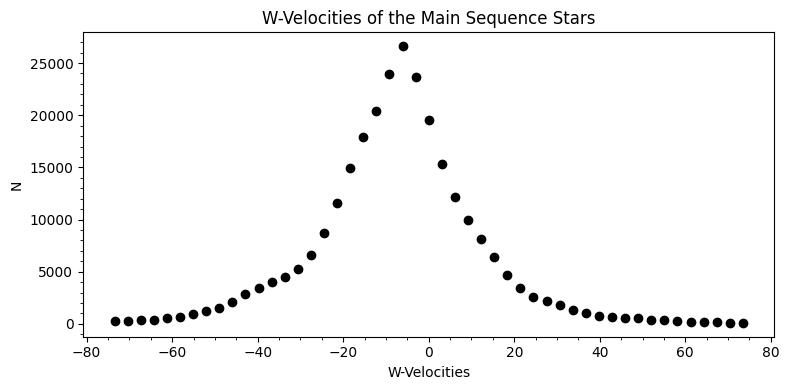

In [18]:
Fig,(linPlot) = plt.subplots(1,figsize=(8,4))
magbins=np.linspace(-75,75,50)
# use np.histogram to actually give us the counts and bins
# in variables that we can work with
N,bin_edges = np.histogram(w_vel_ms,bins=magbins)

# calculate log N and bin centers
logN = np.log10(N)
bin_cent = 0.5*(bin_edges[1:]+bin_edges[:-1])

# make a plot of N(m)
linPlot.scatter(bin_cent,N, color = 'black')
linPlot.set_xlabel('W-Velocities')
linPlot.set_ylabel('N')
linPlot.set_title('W-Velocities of the Main Sequence Stars')
linPlot.minorticks_on()

Fig.tight_layout()
print(f"AVGERAGE: {np.average(w_vel_ms)}, DISPERSION: {np.std(w_vel_ms)}")

C:\Users\bhoom\AppData\Local\Temp\ipykernel_9988\3024360758.py:8: RuntimeWarning: divide by zero encountered in log10
  logN = np.log10(N)


AVGERAGE: -6.6726943500003975, DISPERSION: 7.577871314396819


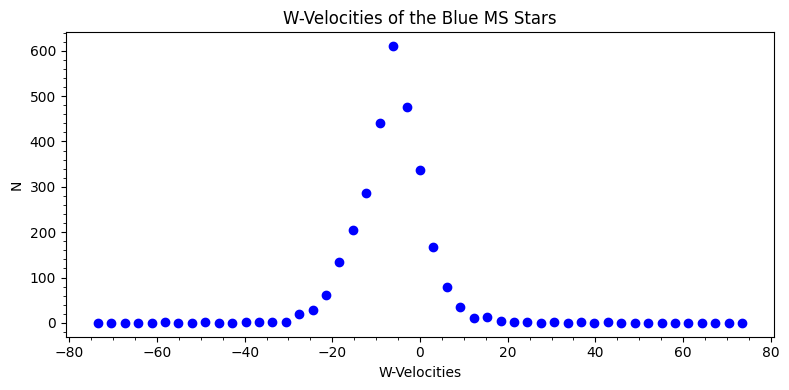

In [19]:
Fig,(linPlot) = plt.subplots(1,figsize=(8,4))
magbins=np.linspace(-75,75,50)
# use np.histogram to actually give us the counts and bins
# in variables that we can work with
N,bin_edges = np.histogram(w_vel_blue,bins=magbins)

# calculate log N and bin centers
logN = np.log10(N)
bin_cent = 0.5*(bin_edges[1:]+bin_edges[:-1])

linPlot.scatter(bin_cent,N, color = 'blue')
linPlot.set_xlabel('W-Velocities')
linPlot.set_ylabel('N')
linPlot.set_title('W-Velocities of the Blue MS Stars')
linPlot.minorticks_on()

Fig.tight_layout()
print(f"AVGERAGE: {np.average(w_vel_blue)}, DISPERSION: {np.std(w_vel_blue)}")

#### Problem 5

In [20]:
filename='Gaia_NSGP.fits'
if not os.path.isfile(filename):
 gaia_data=Table.read('https://burro.case.edu/Academics/Astr323/HW/HW2/'+filename)
 gaia_data.write(filename)
else:
 gaia_data=Table.read(filename)

#Changing the variables to the correct units
gaia_data['parallax'] = gaia_data['parallax']/1000

In [21]:
gaia_data['distance'] = 1/gaia_data['parallax']
gaia_data['absolute_mag'] = 5 + gaia_data['phot_g_mean_mag'] - 5*np.log10(gaia_data['distance'])

In [22]:
bp_rp=gaia_data['bp_rp']
MG= gaia_data['absolute_mag']

Text(0.5, 1.0, 'Full CMD of Gaia Data (5)')

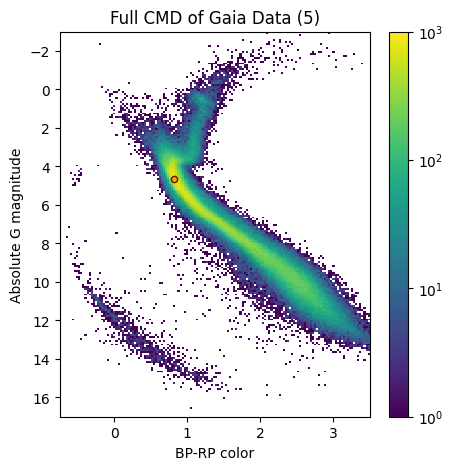

In [23]:
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(111)
h = ax.hist2d(bp_rp, MG, bins=(np.linspace(-0.75,3.5,151),np.linspace(-3,17,201)), norm=LogNorm(1.0,1e3))
cb = fig.colorbar(h[3])
cb.ax.minorticks_off()
ax.invert_yaxis()
ax.set_xlabel('BP-RP color')
ax.set_ylabel('Absolute G magnitude')
ax.set_yticks(np.arange(-2,18,2))
ax.scatter([0.82], [4.67], color='orange', edgecolor='#661100', s=20, lw=1)
ax.set_title("Full CMD of Gaia Data (5)")

In [24]:
main_seq= gaia_data['star_type']==1
rgb = gaia_data['star_type']==2
clump_upper = gaia_data['absolute_mag'] >= 0
clump_lower = gaia_data['absolute_mag'] <= 1


101


C:\Users\bhoom\AppData\Local\Temp\ipykernel_9988\2736641542.py:5: RuntimeWarning: divide by zero encountered in log10
  logdens=np.log10(N/dvol)


Text(0.5, 0, 'Distance (z)')

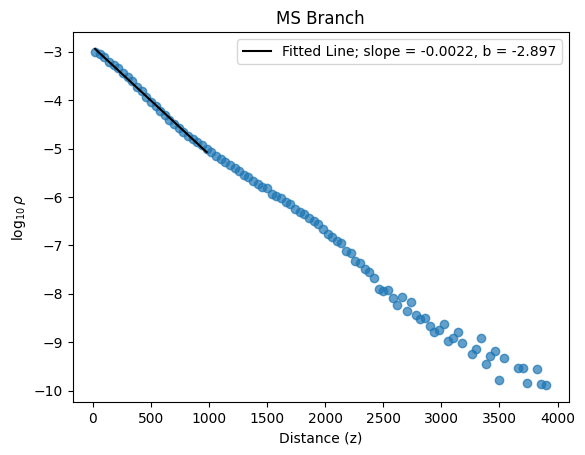

In [25]:
N,edges=np.histogram(gaia_data['distance'][main_seq],bins=100,range=[0,4000])
print(len(edges))
vol=(4.*np.pi/3)*edges**3
dvol=np.diff(vol)
logdens=np.log10(N/dvol)
bincent=0.5*(edges[1:]+edges[:-1])

x_fit_range = (0, 1000)
mask = (bincent >= x_fit_range[0]) & (bincent <= x_fit_range[1])
x_selected = bincent[mask]
y_selected = logdens[mask]

slope, intercept = np.polyfit(x_selected, y_selected, deg=1)
y_fit = slope * x_selected + intercept


plt.scatter(bincent,logdens, alpha = .7)
plt.plot(x_selected, y_fit, color='black', label=f'Fitted Line; slope = {slope:.4f}, b = {intercept:.3f}')
plt.legend()
plt.title("MS Branch")

plt.ylabel(r"$\log_{10}$$\rho$")
plt.xlabel("Distance (z)")


C:\Users\bhoom\AppData\Local\Temp\ipykernel_9988\410617935.py:4: RuntimeWarning: divide by zero encountered in log10
  logdens=np.log10(N/dvol)


Text(0.5, 0, 'Distance (z)')

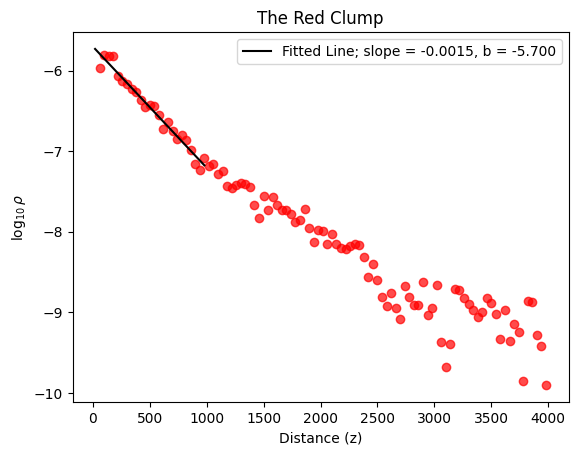

In [26]:
N,edges=np.histogram(gaia_data['distance'][rgb & clump_upper & clump_lower],bins=100,range=[0,4000])
vol=(4.*np.pi/3)*edges**3
dvol=np.diff(vol)
logdens=np.log10(N/dvol)
bincent=0.5*(edges[1:]+edges[:-1])

x_fit_range = (0, 1000)
mask = (bincent >= x_fit_range[0]) & (bincent <= x_fit_range[1])
x_selected = bincent[mask]
y_selected = logdens[mask]


slope, intercept = np.polyfit(x_selected[1:], y_selected[1:], deg=1)
y_fit = slope * x_selected + intercept


plt.scatter(bincent,logdens, color = 'red', alpha = .7)
plt.plot(x_selected, y_fit, color='black', label=f'Fitted Line; slope = {slope:.4f}, b = {intercept:.3f}')
plt.legend()
plt.title("The Red Clump")
plt.ylabel(r"$\log_{10}$$\rho$")
plt.xlabel("Distance (z)")

C:\Users\bhoom\AppData\Local\Temp\ipykernel_9988\368079068.py:4: RuntimeWarning: divide by zero encountered in log10
  logdens=np.log10(N/dvol)


Text(0.5, 0, 'Distance (z)')

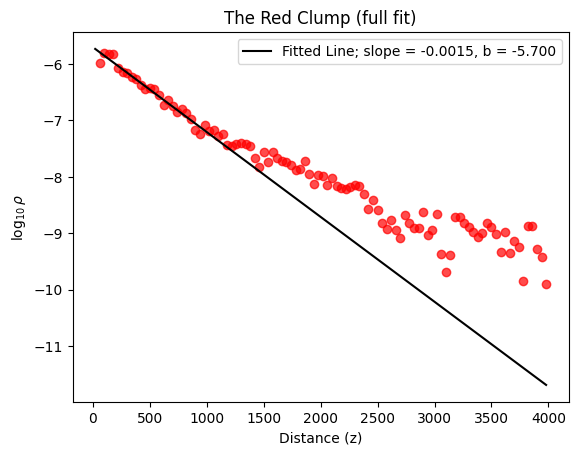

In [27]:
N,edges=np.histogram(gaia_data['distance'][rgb & clump_upper & clump_lower],bins=100,range=[0,4000])
vol=(4.*np.pi/3)*edges**3
dvol=np.diff(vol)
logdens=np.log10(N/dvol)
bincent=0.5*(edges[1:]+edges[:-1])


x_fit_range = (0, 1000)
mask = (bincent >= x_fit_range[0]) & (bincent <= x_fit_range[1])
x_selected = bincent[mask]
y_selected = logdens[mask]


slope, intercept = np.polyfit(x_selected[1:], y_selected[1:], deg=1)
y_fit = slope * bincent + intercept


plt.scatter(bincent,logdens, color = 'red', alpha = .7)
plt.plot(bincent, y_fit, color='black', label=f'Fitted Line; slope = {slope:.4f}, b = {intercept:.3f}')
plt.legend()
plt.title("The Red Clump (full fit)")
plt.ylabel(r"$\log_{10}$$\rho$")
plt.xlabel("Distance (z)")

101


C:\Users\bhoom\AppData\Local\Temp\ipykernel_9988\43359168.py:5: RuntimeWarning: divide by zero encountered in log10
  logdens=np.log10(N/dvol)


Text(0.5, 0, 'Distance (z)')

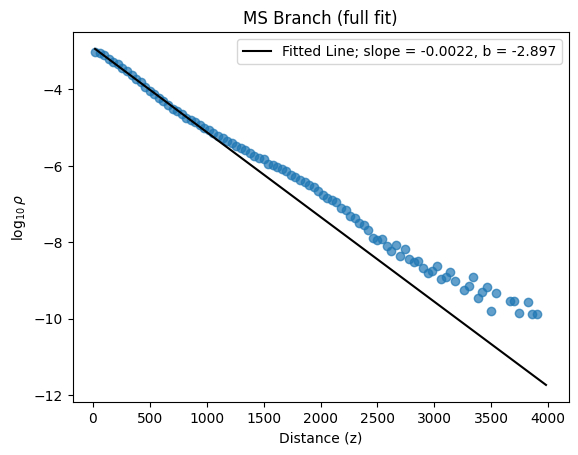

In [28]:
N,edges=np.histogram(gaia_data['distance'][main_seq],bins=100,range=[0,4000])
print(len(edges))
vol=(4.*np.pi/3)*edges**3
dvol=np.diff(vol)
logdens=np.log10(N/dvol)
bincent=0.5*(edges[1:]+edges[:-1])

x_fit_range = (0, 1000)
mask = (bincent >= x_fit_range[0]) & (bincent <= x_fit_range[1])
x_selected = bincent[mask]
y_selected = logdens[mask]

slope, intercept = np.polyfit(x_selected, y_selected, deg=1)
y_fit = slope * bincent + intercept


plt.scatter(bincent,logdens, alpha = .7)
plt.plot(bincent, y_fit, color='black', label=f'Fitted Line; slope = {slope:.4f}, b = {intercept:.3f}')
plt.legend()
plt.title("MS Branch (full fit)")

plt.ylabel(r"$\log_{10}$$\rho$")
plt.xlabel("Distance (z)")